# Importación de librerías

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# Carga de archivos (.txt) y etiquetado

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- CONFIGURACIÓN DE RUTAS ---
bueno_dir = '/content/drive/MyDrive/Colab Notebooks/BUENO'
malo_dir = '/content/drive/MyDrive/Colab Notebooks/MALO'

X_features = []
y_labels = []

def cargar_sustancias(ruta_carpeta, etiqueta):
    conteo = 0
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".txt"):
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            try:
                # Usamos pandas.read_csv, que es más robusto para archivos con decimales ','
                # y permite saltar filas con 'skiprows'. Cambiamos 'sep' a espacio.
                datos_df = pd.read_csv(ruta_completa, sep=' ', decimal=',', skiprows=1, header=None)

                # Convertir todas las columnas a numérico, forzando los errores a NaN
                datos_df = datos_df.apply(pd.to_numeric, errors='coerce')

                # Convertir a numpy y aplanar
                datos = datos_df.values.flatten()

                # DEBUG: Imprimir información sobre el archivo y si está todo NaN
                if np.all(np.isnan(datos)):
                    print(f"Advertencia: Archivo '{archivo}' de la carpeta '{os.path.basename(ruta_carpeta)}' contiene solo NaNs después del procesamiento y será ignorado.")
                else:
                    X_features.append(datos)
                    y_labels.append(etiqueta)
                    conteo += 1
            except Exception as e:
                print(f"Error en {archivo} de la carpeta '{os.path.basename(ruta_carpeta)}': {e}")
    return conteo

# Cargar datos
n_buenos = cargar_sustancias(bueno_dir, 1) # 1 para Sustancia Correcta
n_malos = cargar_sustancias(malo_dir, 0)   # 0 para Otras Sustancias

# --- MODIFICACIÓN PARA MANEJAR LARGOS VARIABLES Y RELLENAR ---
# Solo procesar si X_features no está vacío
if X_features:
    # Encontrar la longitud máxima entre todos los arrays cargados
    max_len = max(len(x) for x in X_features)

    # Rellenar (pad) los arrays más cortos con NaN para que todos tengan la misma longitud
    padded_X_features = []
    for x in X_features:
        if len(x) < max_len:
            # Crear un array de NaN para rellenar
            padding = np.full(max_len - len(x), np.nan)
            padded_X_features.append(np.concatenate((x, padding)))
        else:
            padded_X_features.append(x)
    X = np.array(padded_X_features)
else:
    X = np.array([]) # Si no hay datos, X será un array vacío
    print("Advertencia: No se cargaron datos en X_features.")

y = np.array(y_labels)

print(f"Finalizado: {n_buenos} archivos BUENOS y {n_malos} archivos MALOS cargados.")
print(f"Forma de la matriz X: {X.shape}")

Finalizado: 22 archivos BUENOS y 20 archivos MALOS cargados.
Forma de la matriz X: (42, 242676)


# División del Dataset (Train, Val, Test) y Escalado

In [ ]:
# 1. Separar un 20% para el Test final
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Imputar los valores NaN antes de escalar
# Usamos la media de cada columna del conjunto de entrenamiento para imputar.
# Cambiamos la estrategia a 'constant' para asegurar que todos los NaN sean tratados,
# incluso en columnas completamente NaN.
imputer = SimpleImputer(strategy='constant', fill_value=0) # Rellenar con 0

X_train_val_imputed = imputer.fit_transform(X_train_val)
X_test_imputed = imputer.transform(X_test) # Usar el imputer entrenado con el conjunto de entrenamiento

# 3. Escalar los datos (Fundamental para una ANN)
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"Datos listos.")
print(f"Entrenamiento + Validación: {X_train_val_scaled.shape[0]} muestras")
print(f"Prueba final (Test): {X_test_scaled.shape[0]} muestras")

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


Datos listos.
Entrenamiento + Validación: 33 muestras
Prueba final (Test): 9 muestras


# Definición y Entrenamiento de la ANN

In [ ]:
# Definir la estructura de la red
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_val_scaled.shape[1],)),
    Dropout(0.2), # Ayuda a evitar el sobreajuste
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Salida binaria (0 a 1)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Configurar parada temprana
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar (usamos el 20% de lo restante para validación)
print("Iniciando entrenamiento...")

history = model.fit(
    X_train_val_scaled, y_train_val,
    epochs=50,
    batch_size=5,
    validation_split=0.2, # Divide internamente el set de entrenamiento
    callbacks=[early_stop],
    verbose=1
)

print("Entrenamiento finalizado")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 426ms/step - accuracy: 0.2455 - loss: 6.9232 - val_accuracy: 0.7143 - val_loss: 2.4010
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7235 - loss: 3.3860 - val_accuracy: 0.5714 - val_loss: 2.5380
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4099 - loss: 5.0268 - val_accuracy: 1.0000 - val_loss: 0.1972
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8116 - loss: 1.5084 - val_accuracy: 0.7143 - val_loss: 0.5155
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5934 - loss: 5.5299 - val_accuracy: 0.8571 - val_loss: 0.4438
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7378 - loss: 3.2716 - val_accuracy: 1.0000 - val_loss: 0.0521
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6045 - loss: 2.0516 - val_accuracy: 1.0000 - val_loss: 0.0651
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8069 - loss: 1.2247 - val_accuracy

# Evaluación y Resultados

--- RESULTADOS FINALES ---
Precisión en Test (Accuracy): 88.89%


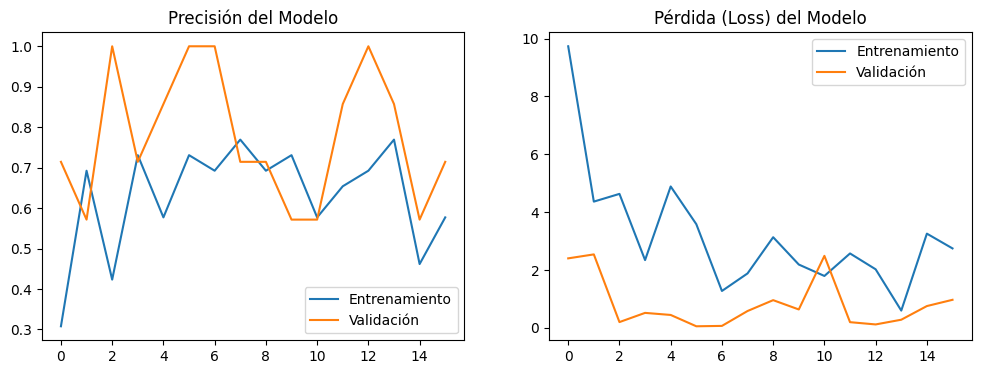

In [ ]:
# Evaluar con el conjunto de Test
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"--- RESULTADOS FINALES ---")
print(f"Precisión en Test (Accuracy): {accuracy*100:.2f}%")

# Gráfico de la evolución del entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss) del Modelo')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
Matriz de Confusión:
[[4 0]
 [1 4]]


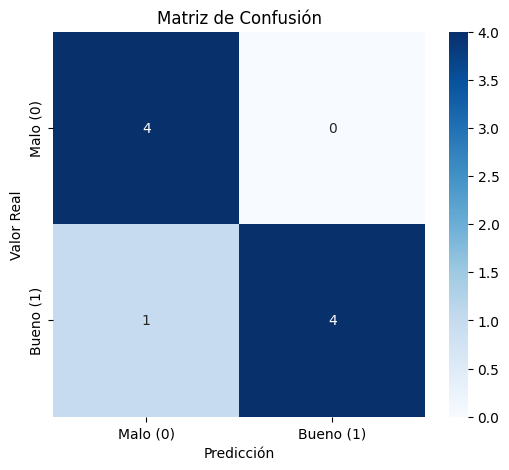

In [ ]:
# Hacer predicciones en el conjunto de prueba
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusión:")
print(cm)

# Visualizar la matriz de confusión (opcional)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malo (0)', 'Bueno (1)'],
            yticklabels=['Malo (0)', 'Bueno (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

# Guardar el modelo

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/modelo_nariz.keras')
print('Modelo guardado correctamente como modelo_sustancias.h5')

Modelo guardado correctamente como modelo_sustancias.h5
